## Why not use linear layers?
- Linear layers:
    - Slow training
    - Overfitting
    - Don't recognize spatial patterns
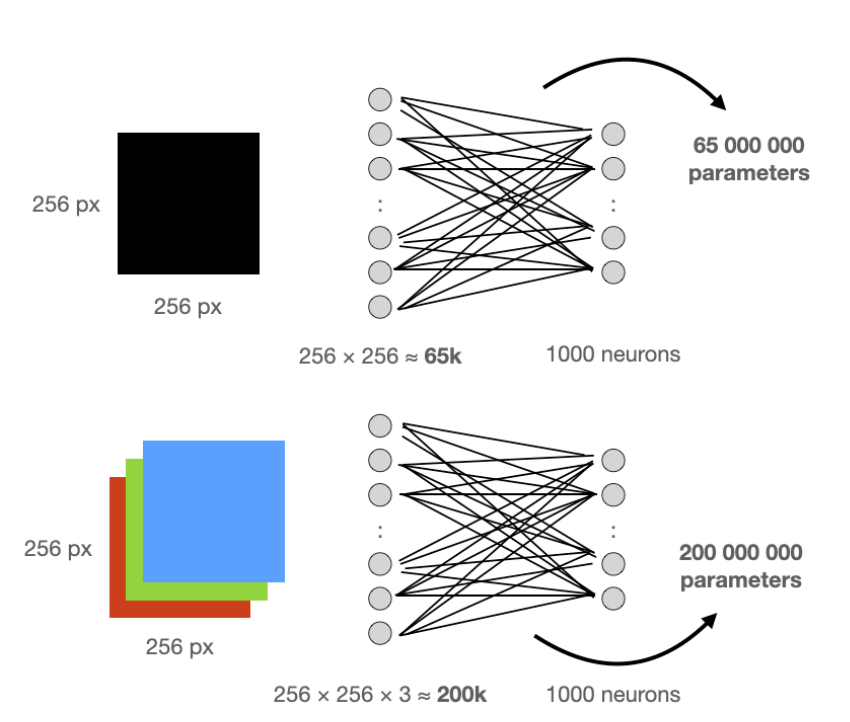

- A better alternative: convolutional layers!
# Convolutional Layer
- Slide filter(s) of parameters over the input
- At each position, perform convolution
- Resulting feature map:
    - Preservers spatial patterns from input
    - Uses fewer parameters than linear layers
- One filter = one feature map
- Apply activations to feature maps
- All feature maps combined form the output
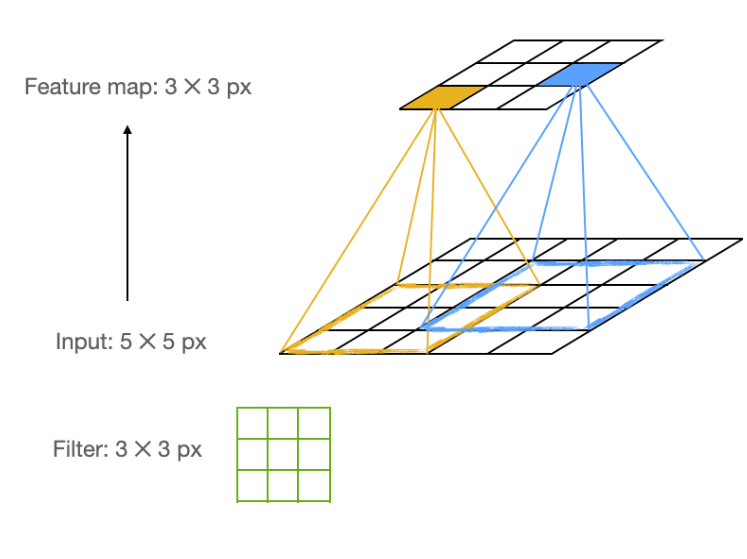

## Convolution
1. Compute dot product of input patch and filter
    - Top- left fild: 2 x 1 = 2
2. Sum the result

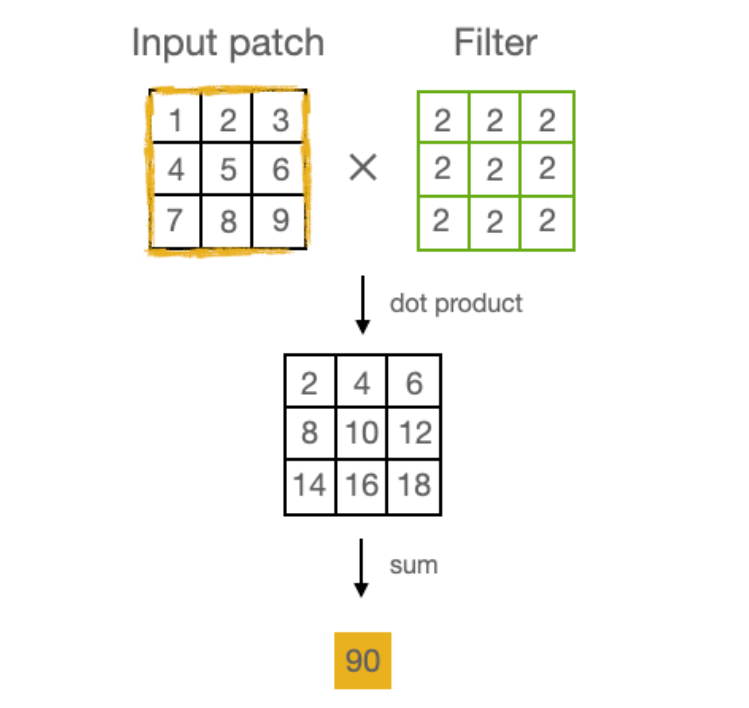

## Zero-padding
- Add zeros to the edges of the input to make it the same size as the filter
- Maintain spatial dimensions of the input and output tensors
- Ensures border pixels are treated equally to others
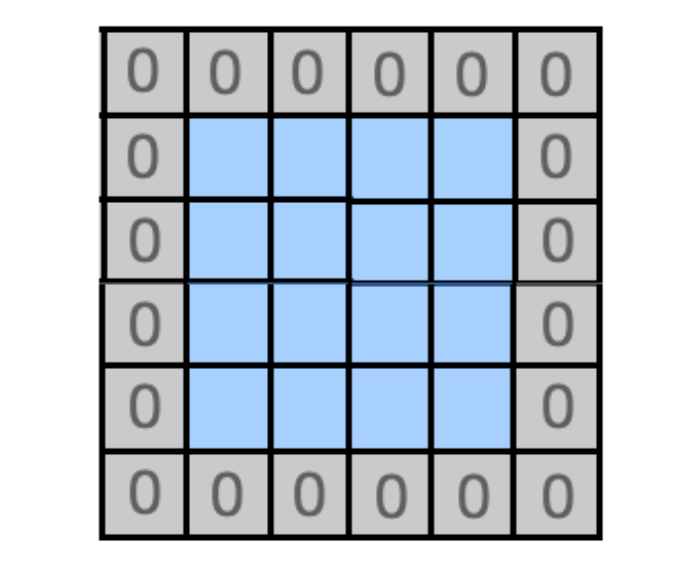

In [ ]:
nn.Conv2d(
    3, 32, kernel_size=3, padding=1
)

## Max Pooling
- Another communally used
- Slide non-overlapping window over input
- At each position, retain only the maximum value
- Used after convolutional layers to reduce spatial dimentions
- ```nn.MaxPool2d(kernel_size=2)```

# Convolutional Neural Network
- ```feature_extractor```: (convolution, activation, pooling), repeated twice and flattened
- ```classifier```: single linear layer

In [ ]:
from torch import nn

class Net(nn.module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ELU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),

        )
        self.classifier = nn.Linear(64*16*16, num_classes)
    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

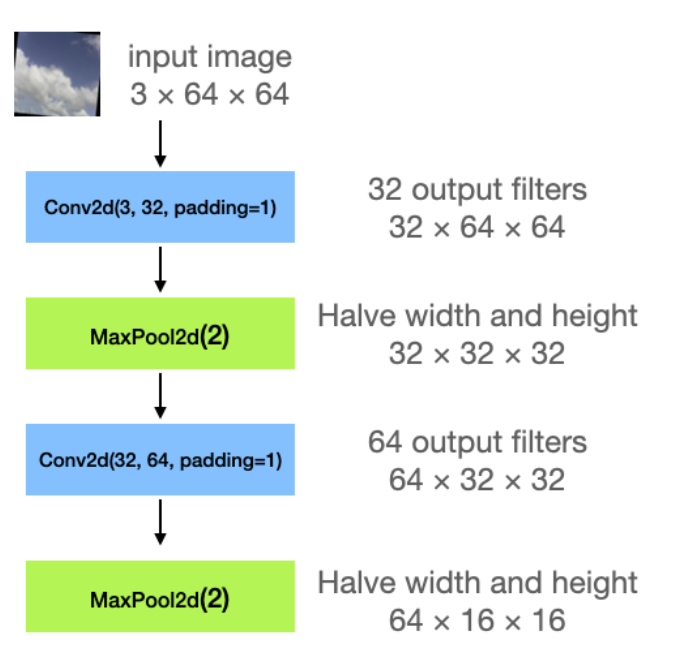